In [ ]:
import numpy as np
from scipy.optimize import minimize

#Método de penalización cuadrática:

Reemplazan el problema original por una serie de subproblemas en los cuales la restricción se presenta mediante términos añadidos a la función objetivo, un término por cada restricción. \\
$μ$ es un parámetro de penalización que controla qué tan fuerte se castiga una función el no cumplir la restricción y es siempre positivo. Este parámetro debe ser muy grande para obligar al algoritmo a acercarse a la región factible. \\
Para estos casos existen una secuencia de funciones de penalización, observaremos el caso más simple que es la función de penalización cuadrática. \\




1. Restricciones de igualdad: \\
Función objetivo a minimizar $$f(x)$$ con restricciones $$h_i(x)=0$$
Función de penalización cuadrática:
$$F(x)=f(x) + \frac{μ}{2} ∑h_i^2(x)$$

En este caso, la función que buscamos minimizar es $F(x)$ y de esta forma se minimiza $f(x)$.







Convierte un problema con restricciones en uno que no tenga restricciones. Cuando los términos de penalización son suaves se pueden utilizar los métodos de optimización de funciones no restringidad para minimizar la función.

Un ejemplo muy simple de esto es:
$$f(x)=(x-2)^2, h(x)=x-1=0$$
La función de penalización cuadrática sería:
$$F(x) = f(x)+\frac{μ}{2} h(x)^2$$
$$F(x)=(x-2)^2 + \frac{μ}{2}(x-1)^2$$

Podemos implementarlo:

In [ ]:
#Función objetivo
def f(x):
  return (x-2)**2

#Restricción
def h(x):
  return x-1


#Método de penalización
def penalty(x):
  def F(x):
    return f(x) + mu * h(x)**2
  res = minimize(F, x0=0)
  return res.x[0], res.fun

In [ ]:
for mu in [1, 10, 100, 1000]:
    x_opt, f_opt = penalty(mu)
    print(f"mu={mu}, x_opt={x_opt:.5f}, f(x)={f_opt:.5f}")

mu=1, x_opt=1.50000, f(x)=0.50000
mu=10, x_opt=1.09091, f(x)=0.90909
mu=100, x_opt=1.00990, f(x)=0.99010
mu=1000, x_opt=1.00100, f(x)=0.99900


Problemas: \\
Uso de derivadas analíticas a partir de la función objetivo es difícil e incluso podría ser inviable. \\
Sufre de mal condicionamiento severo a medida que la precisión requerida aumenta (el parámetro crece), lo que limita su eficacia en comparación con métodos más modernos como el Lagrangiano aumentado.

#Lagrangiano aumentado:

 Una ventaja crucial sobre el método de penalización cuadrática es que el método de Lagrangiano aumentado puede converger sin necesidad de aumentar el parámetro de penalización µ indefinidamente, esto reduce el mal condicionamiento.

In [ ]:


# Método Lagrangiano Aumentado
def augmented_lagrangian_method(mu=1.0, tol=1e-6, max_iter=20):
    x = 0.0   # inicialización
    lam = 0.0 # multiplicador inicial
    for i in range(max_iter):
        def L(x_):
            return f(x_) + lam * h(x_) + (mu/2) * h(x_)**2
        res = minimize(L, x0=x)
        x_new = res.x[0]
        # Actualizamos multiplicador
        lam = lam + mu * h(x_new)
        # Condición de paro
        if abs(x_new - x) < tol:
            break
        x = x_new
    return x, f(x)


print("\nMétodo del Lagrangiano Aumentado")
x_opt, f_opt = augmented_lagrangian_method()
print(f"x_opt={x_opt:.5f}, f(x)={f_opt:.5f}")



Método del Lagrangiano Aumentado
x_opt=1.00030, f(x)=0.99940


No se tienen las derivadas por lo que en los métodos de penalización se puede adaprtar sin derivadas pero la eficiencia es muy baja.

#DFO: Optimización libre de derivadas

Este es un conjunto de métodos diseñados para resolver problemas de optimización cuando no se dispone de derivadas o cuando calcularlas es muy costoso, inexacto o imposible.

Inicialmente este conjunto de métodos son aplicados a casos sin restricciones pero con métodos de penalización se pueden adaptar a problemas con restricciones.

Aspectos importantes de la función:
¿Es ruidosa?
Si el valor cambia de forma impredecible o aleatoria aún cuando se le proporciona la misma entrada varias veces. Esto ocurre, por ejemplo, cuando:

La función es el resultado de una simulación estocástica.

La función depende de mediciones físicas reales, que siempre tienen algo de error.

Hay fluctuaciones numéricas o errores computacionales aleatorios.

El proceso interno tiene alguna componente aleatoria.

# Evolución diferencial (ED)

Se usa cuando la función objetivo es no lineal, no diferenciable o tiene muchos mínimos locales, como suele ocurrir en problemas de diseño óptico:

Inicialización, mutación, recombinación y selección. \
Optimización global. \
No necesita derivadas. \
Es muy robusto ante funciones ruidosas o con errores.

1. Inicialización: \\
Vectores $x_i$ generados aleatoriamente, donde cada $x_i$ representa una potencial solución.

2. Mutación: El operador mutación consiste en la diferencia aritmética entre pares de vectores seleccionados aleagtoriamente. \\
$$v_i = x_{r_1} + F(x_{r_2} - x_{r_3})$$

Donde $v_i$ es el vector mutado y F es un factor de amplificación que evita estancamiento en el proceso de búsqueda.

3. Recombinación: Se mezcla $x_i$ que es un elemento de la población inicial, con el vector mutado $v_i$ bajo un sistema de recombinación en el cual basándonos en una constate de recombinación $C_R$ se construye un vector de prueba $u_i$ componente a componente a partir de $x_i$ y $v_i$.

4. Selección: Se evalúa la función objetivo tando del vector inicial como del vector de prueba, si $f(u_i)$ < $f(x_i)$ el vector de prueba pasa a ser el vector inicial, de lo contrario se conserva igual hasta que un vector de prueba mejore la función objetivo.

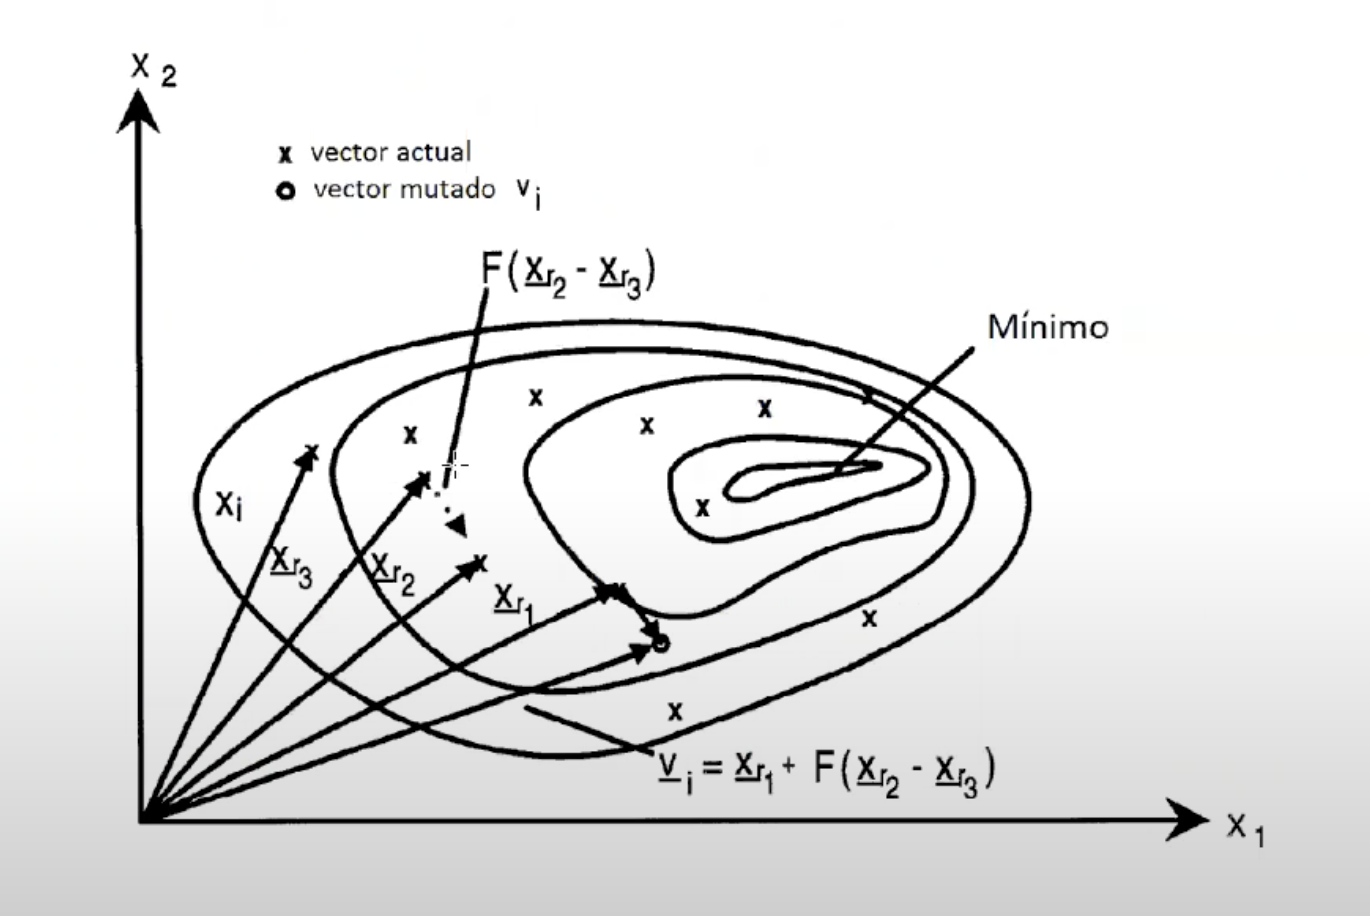

Comparativa:

PSO:



FSS:



DE: Ideal para simulaciones muy costosas

In [ ]:
import numpy as np

# Función original a minimizar
def f(x):
    return (x - 2)**2

# Restricción h(x) = 0
def h(x):
    return x - 1

# Función penalizada
def f_penalizada(x, lambda_pen=1000):
    return f(x) + lambda_pen * (h(x)**2)

def evolucion_diferencial(func, bounds, pop_size=20, F=0.8, CR=0.9, generations=50):
    dim = len(bounds)

    pop = np.random.rand(pop_size, dim)
    for i in range(dim):
        min_b, max_b = bounds[i]
        pop[:, i] = min_b + pop[:, i] * (max_b - min_b)

    fitness = np.array([func(ind[0]) for ind in pop])

    for gen in range(generations):
        for i in range(pop_size):
            idxs = [idx for idx in range(pop_size) if idx != i]
            r1, r2, r3 = np.random.choice(idxs, 3, replace=False)

            mutant = pop[r1] + F * (pop[r2] - pop[r3])
            mutant = np.clip(mutant, [b[0] for b in bounds], [b[1] for b in bounds])

            cross_points = np.random.rand(dim) < CR
            if not np.any(cross_points):
                cross_points[np.random.randint(0, dim)] = True

            trial = np.where(cross_points, mutant, pop[i])

            f_trial = func(trial[0])
            if f_trial < fitness[i]:
                pop[i] = trial
                fitness[i] = f_trial

        best_idx = np.argmin(fitness)
        print(f"Generación {gen+1}: Mejor valor penalizado = {fitness[best_idx]:.6f}")

    best_idx = np.argmin(fitness)
    return pop[best_idx][0], fitness[best_idx]

# Definimos límites amplios para x
bounds = [(-20, 20)]

# Ejecutamos evolución diferencial sobre la función penalizada
mejor_x, mejor_valor_pen = evolucion_diferencial(f_penalizada, bounds, generations=30)

print(f"\nMejor x encontrada: {mejor_x:.4f}")
print(f"Valor penalizado: {mejor_valor_pen:.6f}")
print(f"Valor real de f(x) sin penalización: {f(mejor_x):.6f}")
print(f"Cumplimiento restricción h(x) = {h(mejor_x):.6f} (debería ser cercano a 0)")


Generación 1: Mejor valor penalizado = 48.225001
Generación 2: Mejor valor penalizado = 48.225001
Generación 3: Mejor valor penalizado = 48.225001
Generación 4: Mejor valor penalizado = 4.104069
Generación 5: Mejor valor penalizado = 4.104069
Generación 6: Mejor valor penalizado = 4.104069
Generación 7: Mejor valor penalizado = 1.671552
Generación 8: Mejor valor penalizado = 1.671552
Generación 9: Mejor valor penalizado = 1.007097
Generación 10: Mejor valor penalizado = 1.007097
Generación 11: Mejor valor penalizado = 0.999870
Generación 12: Mejor valor penalizado = 0.999870
Generación 13: Mejor valor penalizado = 0.999870
Generación 14: Mejor valor penalizado = 0.999050
Generación 15: Mejor valor penalizado = 0.999050
Generación 16: Mejor valor penalizado = 0.999050
Generación 17: Mejor valor penalizado = 0.999050
Generación 18: Mejor valor penalizado = 0.999050
Generación 19: Mejor valor penalizado = 0.999010
Generación 20: Mejor valor penalizado = 0.999010
Generación 21: Mejor valor

In [ ]:
import numpy as np

def rastrigin(x):
    """Función objetivo Rastrigin, mínimo en x=0"""
    A = 10
    return A * len(x) + sum([(xi**2 - A * np.cos(2 * np.pi * xi)) for xi in x])

def differential_evolution(func, bounds, pop_size=20, F=0.8, CR=0.9, generations=100):
    """
    Implementación simple de Evolución Diferencial (DE)

    Args:
        func: función objetivo a minimizar
        bounds: lista de tuplas con límites para cada parámetro [(min,max), ...]
        pop_size: tamaño de la población
        F: factor de escala para mutación (0 < F <= 2)
        CR: tasa de recombinación (0 <= CR <= 1)
        generations: número de iteraciones

    Returns:
        Mejor solución encontrada y su valor objetivo
    """
    dim = len(bounds)

    # Inicialización de población
    pop = np.random.rand(pop_size, dim)
    for i in range(dim):
        min_b, max_b = bounds[i]
        pop[:, i] = min_b + pop[:, i] * (max_b - min_b)

    # Evaluar población inicial
    fitness = np.asarray([func(ind) for ind in pop])

    for gen in range(generations):
        for i in range(pop_size):
            # Selección de tres individuos distintos a i
            idxs = [idx for idx in range(pop_size) if idx != i]
            r1, r2, r3 = np.random.choice(idxs, 3, replace=False)

            # Mutación
            mutant = pop[r1] + F * (pop[r2] - pop[r3])

            # Asegurar límites
            mutant = np.clip(mutant, [b[0] for b in bounds], [b[1] for b in bounds])

            # Recombinación (crossover)
            cross_points = np.random.rand(dim) < CR
            # Asegurar que al menos una dimensión venga del mutante
            if not np.any(cross_points):
                cross_points[np.random.randint(0, dim)] = True

            trial = np.where(cross_points, mutant, pop[i])

            # Evaluar nuevo candidato
            f_trial = func(trial)

            # Selección
            if f_trial < fitness[i]:
                pop[i] = trial
                fitness[i] = f_trial

        # Imprimir el mejor resultado en la generación actual
        best_idx = np.argmin(fitness)
        print(f"Generación {gen+1}: Mejor valor = {fitness[best_idx]:.6f}")

    # Mejor solución global
    best_idx = np.argmin(fitness)
    return pop[best_idx], fitness[best_idx]

# Parámetros y límites para el problema (ejemplo 2D)
bounds = [(-5.12, 5.12), (-5.12, 5.12)]

# Ejecutar DE para minimizar Rastrigin
best_solution, best_value = differential_evolution(rastrigin, bounds, generations=50)

print("\nMejor solución encontrada:", best_solution)
print("Valor objetivo:", best_value)


Generación 1: Mejor valor = 10.046407
Generación 2: Mejor valor = 6.432054
Generación 3: Mejor valor = 6.432054
Generación 4: Mejor valor = 6.432054
Generación 5: Mejor valor = 6.432054
Generación 6: Mejor valor = 6.432054
Generación 7: Mejor valor = 6.432054
Generación 8: Mejor valor = 6.432054
Generación 9: Mejor valor = 6.432054
Generación 10: Mejor valor = 2.584821
Generación 11: Mejor valor = 2.584821
Generación 12: Mejor valor = 2.584821
Generación 13: Mejor valor = 2.584821
Generación 14: Mejor valor = 2.584821
Generación 15: Mejor valor = 2.584821
Generación 16: Mejor valor = 2.584821
Generación 17: Mejor valor = 2.584821
Generación 18: Mejor valor = 2.576380
Generación 19: Mejor valor = 1.771422
Generación 20: Mejor valor = 1.771422
Generación 21: Mejor valor = 1.771422
Generación 22: Mejor valor = 1.771422
Generación 23: Mejor valor = 1.771422
Generación 24: Mejor valor = 1.771422
Generación 25: Mejor valor = 0.642541
Generación 26: Mejor valor = 0.642541
Generación 27: Mejor

#Algortimo de Evolución Diferencial

Cuando hay estancamientos se puede usar K-means para agrupar y encontrar varios mínimos locales.

In [ ]:
import random
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import math
import copy
import time

class particleDE(object):
    def __init__(self,dimention,lower=None,upper=None):
        self.solution=[]
        self.lower=lower
        self.upper=upper
        for i in range(dimention):
            if(lower!=None and upper!=None):
                self.solution=np.append(self.solution,(random.uniform(lower[i],upper[i])))
            else:
                self.solution=np.apppend(self.solution,float(random.random()))

        self.value=sys.float_info.max


class algorithmDE(object):
    def __init__(self,dimention,populationSize,lower,upper,function,maxIter,breakCriteria=None,F=0.7,C=0.5,seed=None):
        self.dimention=dimention
        self.particles=[particleDE(dimention,lower,upper) for i in range(populationSize)]
        self.maxIter=maxIter
        self.lower=lower
        self.upper=upper
        self.populationSize=populationSize
        self.function=function
        self.breakCriteria=breakCriteria
        self.F=F
        self.C=C
        self.seed=seed
        self.mutantV=particleDE(dimention,lower,upper)
        self.trialV=[particleDE(dimention,lower,upper) for i in range(populationSize)]
        self.bestParticle=particleDE(dimention,lower,upper)
        self.bestParticle.value=sys.float_info.max
        self.bestIndx=None
        plt.ion()
        self.fig= plt.figure()
        self.fig.canvas.draw()
        self.fig.canvas.flush_events()


    def run(self):
        counter=0
        if(self.seed!=None):
            random.seed(9001)
        while counter<self.maxIter:
            for idx in range(self.populationSize):
                r1=random.randrange(self.populationSize)
                r2=random.randrange(self.populationSize)
                while r1==r2:
                    r2=random.randrange(self.populationSize)
                r3=random.randrange(self.populationSize)
                while r3 == r1 or r3==r2:
                    r3=random.randrange(self.populationSize)
                self.mutantV.solution=self.particles[r1].solution+self.F*(self.particles[r2].solution-self.particles[r3].solution)
                J_r=random.randrange(self.dimention)
                for j in range(self.dimention):
                    r_cj=random.random()
                    if r_cj<self.C or j==J_r:
                        self.trialV[idx].solution[j]=copy.deepcopy(self.mutantV.solution[j])
                    else:
                        self.trialV[idx].solution[j]=self.particles[idx].solution[j]
                self.trialV[idx].value    = self.function(self.trialV[idx].solution)
                self.particles[idx].value = self.function(self.particles[idx].solution)
                if self.trialV[idx].value<self.particles[idx].value:
                    self.particles[idx].solution=copy.deepcopy(self.trialV[idx].solution)
                    self.particles[idx].value=copy.deepcopy(self.trialV[idx].value)
                if self.breakCriteria!=None:
                    if self.particles[idx].value<self.breakCriteria:
                        self.bestIndx=idx
                        break;

            if self.bestIndx!=None:
                return self.particles[self.bestIndx].solution,self.particles[self.bestIndx].value
            for idx in range(self.populationSize):
                if self.particles[idx].value<self.bestParticle.value:
                    self.bestParticle=copy.deepcopy(self.particles[idx])
            counter+=1
            self.plotear(counter,self.bestIndx)
        return self.bestParticle.solution,self.bestParticle.value

    def plotear(self,counter,idxBest):

        x1 = np.arange(-200, 200, 0.25)
        x2 = np.arange(-200, 200, 0.25)
        x1, x2 = np.meshgrid(x1, x2)

        Z = x1**2+x2**2
        #aqui estoy pleteando la funcion de himelblau
        #Z = ((x1**2+x2-11)**2)+(x1+x2**2-7)**2
        #Z = x1**2+2*x2**2-0.3*np.cos(3*math.pi*x1)-0.4*np.cos(4*math.pi*x2)+0.7

        #fig=plt.figure(counter)

        levels=[0,1,10,15,20,30,40,50,70,90,100,150,200,300,400,1500,2500,3500,5000,10000]
        plt.contour(x1,x2,Z,levels,cmap=cm.brg,zorder=-1)

        #print(idxBest)

        X=[b.solution[0] for b in self.particles]
        Y=[b.solution[1] for b in self.particles]
        plt.scatter(X,Y, marker='o',color='r')
        plt.xlim(-10, 10)
        plt.ylim(-10, 10)
        self.fig.canvas.draw()
        self.fig.canvas.flush_events()
        self.fig.clear()








#Ejemplo de ejecución

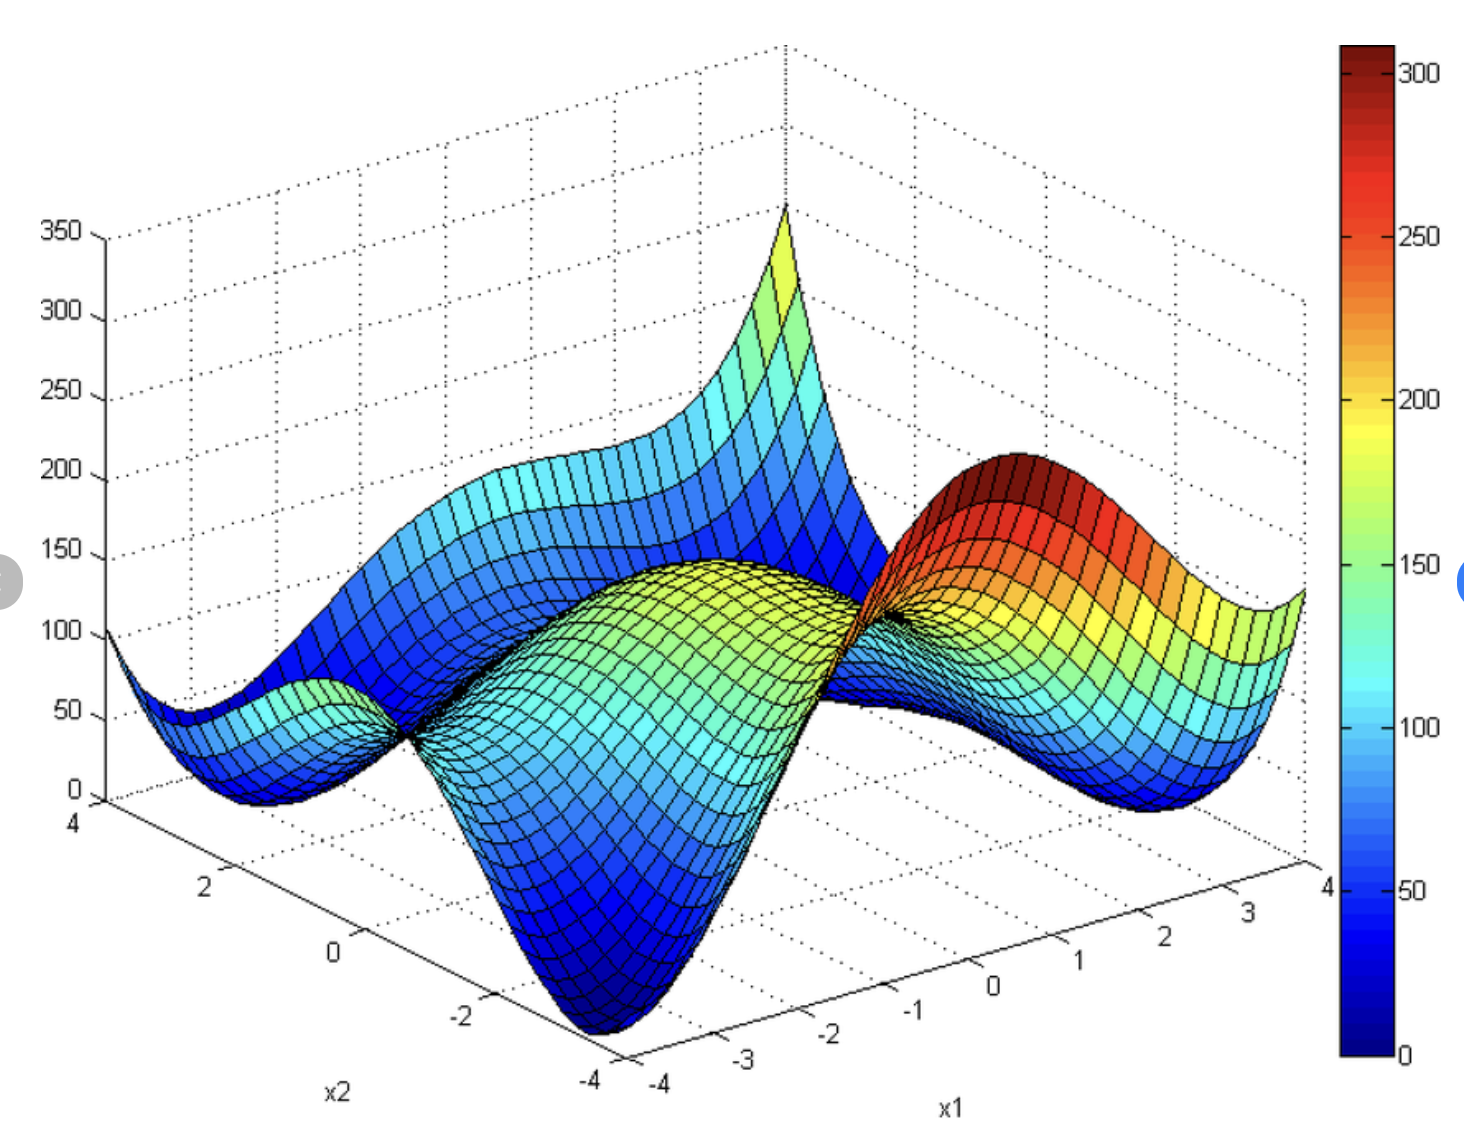.   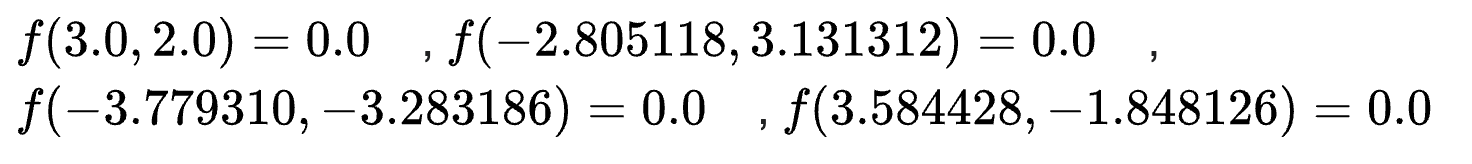

In [ ]:
def himmelblau(x):

    x1, x2 = x
    return (x1**2 + x2 - 11)**2 + (x1 + x2**2 - 7)**2


lower = [-10,-10]
upper = [10,10]
breakCriteria = 0.00005
algoritmo = algorithmDE(dimention=2, lower=lower, upper=upper,
            function=himmelblau, populationSize=30, maxIter=100,
            breakCriteria=breakCriteria, F=0.5, C=0.2, seed=9001)

a = algoritmo.run()
print(a)



(array([ 3.58426068, -1.84933051]), np.float64(2.4141039096996743e-05))


<Figure size 640x480 with 0 Axes>